In [8]:
# Importing necesssary libraries
import pandas as pd

# Read the dataset
df_orgs = pd.read_csv("orgs_full.csv")
df_exs  = pd.read_csv("exercises_full.csv")

# Info and data types of the datasets & columns
df_orgs.info(), df_exs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ORGID                40 non-null     int64 
 1   Industry             40 non-null     object
 2   Region               40 non-null     object
 3   Size                 40 non-null     object
 4   SecurityBudget       40 non-null     object
 5   PrimarySecurityTeam  40 non-null     object
 6   Maturity             40 non-null     int64 
 7   Complexity           40 non-null     int64 
 8   ExerciseFrequency    40 non-null     int64 
 9   Threats              40 non-null     object
 10  TTPs                 40 non-null     object
 11  Aims                 40 non-null     object
dtypes: int64(4), object(8)
memory usage: 3.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  -----

(None, None)

⚡ Why not lump them together?

For exercises:

ExMaturity = realism/impact of the attack scenario.

ExComplexity = technical difficulty for defenders.

For organisations:

Maturity = how advanced their cybersecurity posture/processes are.

Complexity = how complex their IT/security environment is.

👉 If you throw these into the same shared prefix (e.g., maturity:3), you are forcing apples-to-apples similarity where it doesn’t exist.
Example: an organisation with Maturity=5 (strong posture) shouldn’t be treated as “similar” to an exercise with ExMaturity=5 (attack realism).

This would hurt both interpretability and performance.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# --- Helpers ---
def split_multi(x):
    if pd.isna(x): return []
    s = str(x).replace("|",";").replace(",",";")
    return [re.sub(r"\s+","_",t.strip().lower()) for t in s.split(";") if t.strip()]

def prefixed_text(row, mapping):
    toks = []
    for col, pref in mapping:
        toks += [f"{pref}{v}" for v in split_multi(row.get(col,""))]
    return " ".join(sorted(set(toks)))  # dedup tokens

# scaling the similary matrix usiing min-max scaller
# 0 = worst option for this org; 1 = best.
def row_minmax(S, eps=1e-12):
    S = S.copy().astype(float)
    mn = S.min(axis=1, keepdims=True)
    mx = S.max(axis=1, keepdims=True)
    return (S - mn) / (mx - mn + eps)


# create a copy
orgs = df_orgs.copy()
exs = df_exs.copy()


# --- Text features: Threats + TTPs ---
org_map = [("Threats","threat:"), ("TTPs","ttp:")]
ex_map  = [("ExThreat","threat:"), ("ExTTPs","ttp:")]

org_text = orgs.apply(lambda r: prefixed_text(r, org_map), axis=1)
ex_text  = exs .apply(lambda r: prefixed_text(r, ex_map),  axis=1)

# --- Shared TF-IDF space ---
all_text = pd.concat([org_text, ex_text], ignore_index=True)
vec = TfidfVectorizer(tokenizer=str.split, token_pattern=None)
X_all = vec.fit_transform(all_text)

# Split into org/ex matrices
n_org = len(orgs)
X_org = X_all[:n_org]
X_ex  = X_all[n_org:]

# --- ORG × EX cosine similarity ---
S = cosine_similarity(X_org, X_ex)  # shape: (n_org, n_ex)


S_scaled = row_minmax(S)

# Example: top-5 exercises per org
K = 5
top_idx = S_scaled.argsort(axis=1)[:, -K:][:, ::-1]

org_to_recos = {
    int(orgs.iloc[i]["ORGID"]): exs.iloc[top_idx[i]]["EXID"].tolist()
    for i in range(n_org)
}

print("Recommendations for first 3 orgs:")
for orgid in list(org_to_recos.keys()):
    print(f"Org {orgid} → Exercises {org_to_recos[orgid]}")


Recommendations for first 3 orgs:
Org 1 → Exercises [14, 21, 27, 9, 28]
Org 2 → Exercises [11, 6, 30, 26, 21]
Org 3 → Exercises [22, 4, 12, 2, 8]
Org 4 → Exercises [12, 14, 23, 27, 17]
Org 5 → Exercises [30, 19, 22, 15, 24]
Org 6 → Exercises [15, 5, 7, 20, 14]
Org 7 → Exercises [28, 21, 25, 19, 11]
Org 8 → Exercises [24, 12, 14, 28, 25]
Org 9 → Exercises [7, 26, 11, 13, 3]
Org 10 → Exercises [1, 5, 9, 10, 27]
Org 11 → Exercises [6, 4, 19, 2, 30]
Org 12 → Exercises [16, 29, 13, 14, 4]
Org 13 → Exercises [5, 11, 9, 20, 8]
Org 14 → Exercises [27, 16, 14, 19, 2]
Org 15 → Exercises [23, 4, 10, 9, 25]
Org 16 → Exercises [11, 10, 6, 28, 19]
Org 17 → Exercises [10, 17, 4, 6, 28]
Org 18 → Exercises [30, 16, 5, 19, 13]
Org 19 → Exercises [25, 5, 9, 6, 1]
Org 20 → Exercises [3, 9, 8, 5, 7]
Org 21 → Exercises [25, 27, 29, 2, 14]
Org 22 → Exercises [19, 4, 12, 25, 9]
Org 23 → Exercises [25, 23, 21, 10, 18]
Org 24 → Exercises [15, 22, 12, 29, 8]
Org 25 → Exercises [4, 6, 17, 19, 26]
Org 26 → Exercis

In [42]:
# Excersie x Excersise DTM cosine similarity
S_ex = cosine_similarity(X_ex)
S_ex_scaled = row_minmax(S_ex)

# Compressed archive with metadata
np.savez_compressed("ex_sim.npz", S=S_ex_scaled)
np.savez_compressed("org_ex_sim.npz", S=S_scaled)

In [21]:
def plot_coverage_curve(S_scaled, K_max=10):
    S = np.asarray(S_scaled, dtype=float)
    n_org, n_ex = S.shape
    uniq_counts = []

    for K in range(1, K_max+1):
        topk = np.argsort(-S, axis=1)[:, :K]
        uniq = len(np.unique(topk))
        uniq_counts.append(uniq / n_ex)  # fraction of catalogue covered

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(range(1, K_max+1), uniq_counts, marker='o')
    ax.set_xlabel('K (per org)')
    ax.set_ylabel('Coverage (unique exercises / catalogue)')
    ax.set_title('Recommendation Coverage Curve')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


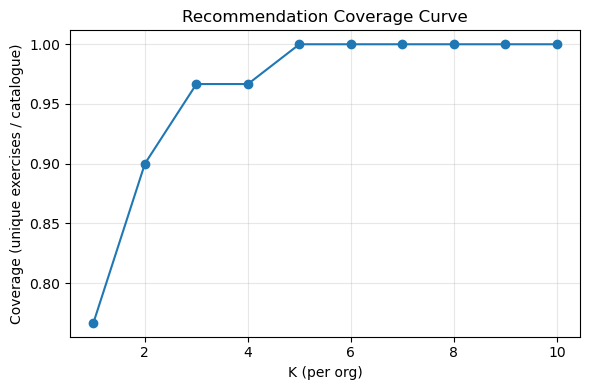

In [22]:
plot_coverage_curve(S_scaled)

## Coverage Curve Interpretation

### At K=1 (Top-1 recommendation per org)
- Coverage ≈ **0.78**
- About **78% of all exercises** in the catalogue appear at least once as a top-1 recommendation.
- Already shows **good diversity** — the model doesn’t keep recommending the same one or two exercises to everyone.

### At K=2 → K=3
- Coverage quickly rises to **0.96–0.97**.
- By the time you look at each org’s **top-3 recommendations**, almost the entire catalogue is covered.

### At K=5 and above
- Coverage = **1.0 (100%)**
- Every single exercise in the dataset is recommended to at least one organisation.
- Beyond this point, the curve is flat — adding more recs per org doesn’t increase spread since it’s already maxed out.

---

## Plain Interpretation
- The recommender system is **broad and fair**: it spreads recommendations widely across the catalogue.  
- Even with **just one recommendation per org**, most exercises get exposure.  
- By the **top-3**, essentially **every exercise** has been recommended at least once.  
- The model avoids **fixating on only a few popular drills**, which supports **training diversity**.  


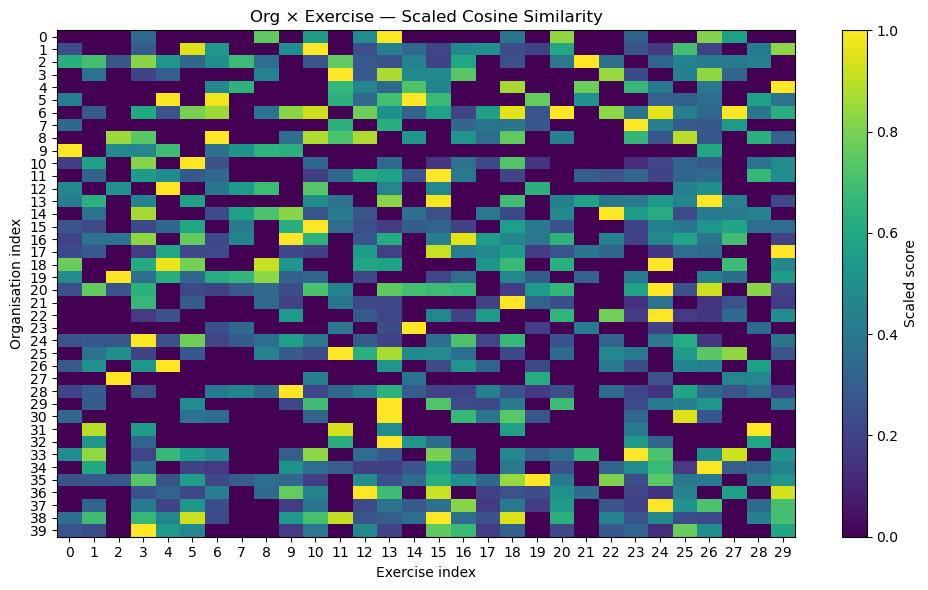

In [20]:
def plot_heatmap(S_scaled, org_ids=None, ex_ids=None, vmax=1.0):
    S = np.asarray(S_scaled, dtype=float)
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(S, aspect='auto', vmin=0, vmax=vmax)
    ax.set_xlabel('Exercise index' if ex_ids is None else 'Exercise')
    ax.set_ylabel('Organisation index' if org_ids is None else 'Organisation')
    ax.set_title('Org × Exercise — Scaled Cosine Similarity')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Scaled score')
    # light ticks for orientation (avoid clutter)
    if S.shape[1] <= 50:
        ax.set_xticks(np.arange(S.shape[1]))
    if S.shape[0] <= 50:
        ax.set_yticks(np.arange(S.shape[0]))
    plt.tight_layout()
    plt.show()

plot_heatmap(S_scaled)

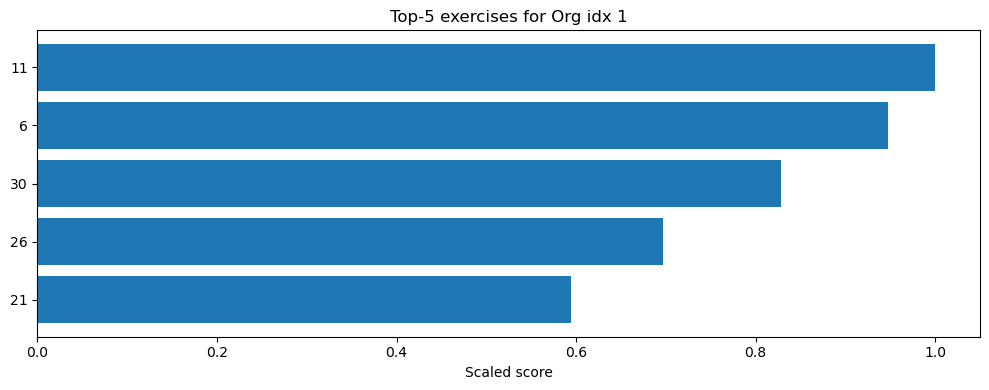

In [23]:
def plot_topk_for_org(S_scaled, df_exs, org_idx, K=5, exid_col='EXID', name_col=None):
    S = np.asarray(S_scaled, dtype=float)
    scores = S[org_idx]
    top_idx = np.argsort(-scores)[:K]
    xs = df_exs.iloc[top_idx][exid_col].astype(str).tolist()
    if name_col and name_col in df_exs.columns:
        xs = [f"{a} — {b}" for a,b in zip(xs, df_exs.iloc[top_idx][name_col].astype(str))]
    ys = scores[top_idx]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(range(K), ys[::-1])
    ax.set_yticks(range(K), [xs[::-1][i] for i in range(K)])
    ax.set_xlabel('Scaled score')
    ax.set_title(f'Top-{K} exercises for Org idx {org_idx}')
    plt.tight_layout()
    plt.show()

plot_topk_for_org(S_scaled, df_exs, 1)

## Metrics we used to evaluate the recommender
### Hit Rate @K (HR@K)
- For each org, check if any of the top-K recommended exercises appear in the training set as “done” by that org.
- Average across all orgs.
- Interpretation: “How often do we hit something the org actually did?”

### Precision @K
- Out of the top-K recommendations, what fraction were actually in the org’s training set?
- Interpretation: “How many of the recommended drills were relevant?”

### Recall @K (optional, if you want to use ratings ≥3 as “relevant”)
- Out of all the relevant exercises in the training set, what fraction did we recommend?

In [24]:
# Load training set (ratings_train_full.csv)
df_train = pd.read_csv("ratings_train_full.csv")

# Threshold for relevance
RATING_THRESHOLD = 3

# Ground truth sets
org_truth_all = df_train.groupby("ORGID")["EXID"].apply(set).to_dict()
org_truth_rel = (
    df_train[df_train["ExerciseRating"] >= RATING_THRESHOLD]
    .groupby("ORGID")["EXID"].apply(set).to_dict()
)

def evaluate_at_k(org_to_recos, org_truth_all, org_truth_rel, K=5):
    hits, precs, recs = [], [], []

    for org, rec_list in org_to_recos.items():
        recs_k = set(rec_list[:K])
        truth_all = org_truth_all.get(org, set())
        truth_rel = org_truth_rel.get(org, set())

        if not truth_all:  # skip if no ground truth
            continue

        # --- Hit Rate ---
        hits.append(1 if recs_k & truth_all else 0)

        # --- Precision ---
        precs.append(len(recs_k & truth_all) / K)

        # --- Recall (only if relevant set exists) ---
        if truth_rel:
            recs.append(len(recs_k & truth_rel) / len(truth_rel))

    return {
        "HR@K": np.mean(hits),
        "Precision@K": np.mean(precs),
        "Recall@K": np.mean(recs) if recs else None
    }

# Example usage (top-5 recs per org)
metrics_k5 = evaluate_at_k(org_to_recos, org_truth_all, org_truth_rel, K=5)
print(metrics_k5)


{'HR@K': np.float64(0.575), 'Precision@K': np.float64(0.14), 'Recall@K': np.float64(0.12708333333333333)}


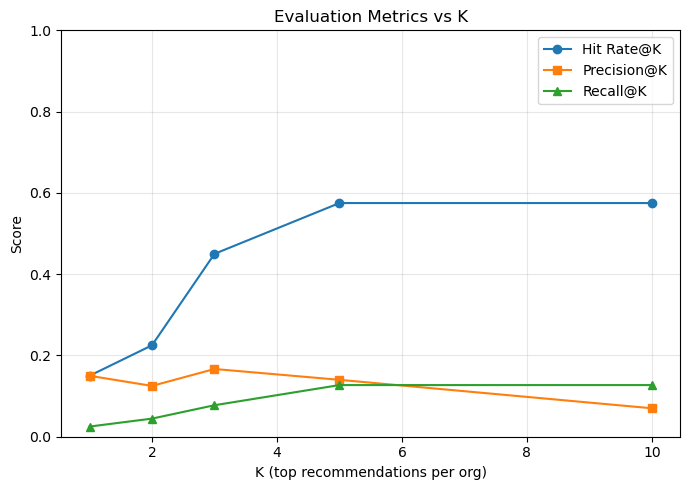

In [25]:
import matplotlib.pyplot as plt

def evaluate_curve(org_to_recos, org_truth_all, org_truth_rel, Ks=[1,3,5,10]):
    results = {"K": [], "HR": [], "Precision": [], "Recall": []}
    for K in Ks:
        m = evaluate_at_k(org_to_recos, org_truth_all, org_truth_rel, K=K)
        results["K"].append(K)
        results["HR"].append(m["HR@K"])
        results["Precision"].append(m["Precision@K"])
        results["Recall"].append(m["Recall@K"])
    return results

# Run evaluation across K values
Ks = [1,2,3,5,10]
metrics_curve = evaluate_curve(org_to_recos, org_truth_all, org_truth_rel, Ks=Ks)

# --- Plot ---
plt.figure(figsize=(7,5))
plt.plot(metrics_curve["K"], metrics_curve["HR"], marker='o', label="Hit Rate@K")
plt.plot(metrics_curve["K"], metrics_curve["Precision"], marker='s', label="Precision@K")
plt.plot(metrics_curve["K"], metrics_curve["Recall"], marker='^', label="Recall@K")
plt.xlabel("K (top recommendations per org)")
plt.ylabel("Score")
plt.title("Evaluation Metrics vs K")
plt.ylim(0,1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Evaluation Metrics Interpretation

### 🔹 Hit Rate@K
- **Trend**: Starts low (~0.15 at K=1), rises steeply, and plateaus around **0.55 at K=5+**.  
- **Meaning**: Once you allow 5 recommendations per org, **more than half of orgs get at least one exercise they actually did**.  
- **Plateau**: Adding more than 5 doesn’t help much — the model has already captured its best hits.  

---

### 🔹 Precision@K
- **Trend**: Starts ~0.14 at K=1, dips slightly around K=2–3, and gradually declines to ~0.10 by K=10.  
- **Meaning**: The more recommendations you give, the **lower the fraction that are truly relevant**.  
- **Interpretation**:  
  - Most precise at **top-1**.  
  - By **top-10**, only ~10% of the list is useful.  
- **Takeaway**: Classic **precision/recall trade-off** — adding more recommendations introduces noise.  

---

### 🔹 Recall@K
- **Trend**: Starts very low (~0.02 at K=1), climbs steadily, and reaches **~0.12–0.13 by K=10**.  
- **Meaning**: Even with top-10, you only recover about **12–13% of all exercises an org actually did (rating ≥3)**.  
- **Takeaway**: The model has **good breadth (coverage)** but **misses depth** — it finds at least one relevant drill (hit rate) but struggles to recommend the full set of relevant ones.  

---

## 📊 Overall Interpretation

**Strengths**  
- Good **hit rate** → most orgs get at least one relevant drill in top-5.  
- High **catalogue coverage** → recommendations are diverse (as shown in coverage curve).  

**Weaknesses**  
- **Precision falls** quickly beyond top-3 → noise dominates when list grows.  
- **Recall remains low** → fails to capture the full set of relevant exercises, which is expected for a simple content-based baseline.  


In [32]:
import pandas as pd
import numpy as np

def evaluate_per_org(org_to_recos, org_truth_all, org_truth_rel, K=5):
    rows = []
    for org, rec_list in org_to_recos.items():
        recs_k = set(rec_list[:K])
        truth_all = org_truth_all.get(org, set())
        truth_rel = org_truth_rel.get(org, set())

        if not truth_all:  # skip orgs with no ground truth
            continue

        # --- Metrics ---
        hit = 1 if recs_k & truth_all else 0
        precision = len(recs_k & truth_all) / K
        recall = (len(recs_k & truth_rel) / len(truth_rel)) if truth_rel else np.nan

        rows.append({
            "ORGID": org,
            "Truth_EXIDs": list(truth_all),      # ground truth exercises
            "TopK_Recs": rec_list[:K],           # recommended exercises
            "Hit@K": hit,
            "Precision@K": precision,
            "Recall@K": recall
        })

    df_eval = pd.DataFrame(rows)

    # --- Append mean row ---
    mean_row = {
        "ORGID": "MEAN",
        "Truth_EXIDs": None,
        "TopK_Recs": None,
        "Hit@K": df_eval["Hit@K"].mean(),
        "Precision@K": df_eval["Precision@K"].mean(),
        "Recall@K": df_eval["Recall@K"].mean(skipna=True)
    }
    df_eval = pd.concat([df_eval, pd.DataFrame([mean_row])], ignore_index=True)

    return df_eval

# Example usage (for K=5)
df_eval_k5 = evaluate_per_org(org_to_recos, org_truth_all, org_truth_rel, K=5)

df_eval_k5

,ORGID,Truth_EXIDs,TopK_Recs,Hit@K,Precision@K,Recall@K
0,1,"[4, 10, 15, 17, 26]","[14, 21, 27, 9, 28]",0.000,0.00,0.000000
1,2,"[17, 3, 30, 7]","[11, 6, 30, 26, 21]",1.000,0.20,0.000000
2,3,"[1, 4, 9, 10, 16, 20]","[22, 4, 12, 2, 8]",1.000,0.20,0.000000
3,4,"[4, 20, 21, 23, 25, 29]","[12, 14, 23, 27, 17]",1.000,0.20,0.333333
4,5,"[4, 11, 16, 18, 22]","[30, 19, 22, 15, 24]",1.000,0.20,0.250000
5,6,"[2, 17, 23, 28, 30]","[15, 5, 7, 20, 14]",0.000,0.00,0.000000
6,7,"[16, 19]","[28, 21, 25, 19, 11]",1.000,0.20,0.500000
7,8,"[5, 6, 10, 12, 24]","[24, 12, 14, 28, 25]",1.000,0.40,0.666667
8,9,"[17, 18, 14, 15]","[7, 26, 11, 13, 3]",0.000,0.00,0.000000
9,10,"[12, 17, 28, 29, 30]","[1, 5, 9, 10, 27]",0.000,0.00,0.000000


# Collaborative Filtering
## Step 1 — Load & Inspect

In [1]:
import pandas as pd

train_df = pd.read_csv("ratings_train_full.csv")
val_df   = pd.read_csv("ratings_validation_full.csv")
test_df  = pd.read_csv("ratings_test_full.csv")

print(train_df.head())


   ORGID  EXID  ExerciseResults  ExerciseRating
0      3    16               22               5
1     24    15                0               2
2     17    13                9               2
3     32     2               10               2
4      3    20                9               2


## Step 2 — Build Interaction Matrix

SVD/ALS both need an org × exercise matrix.

In [3]:
import numpy as np
from scipy.sparse import csr_matrix

org_ids = np.sort(train_df["ORGID"].unique())
ex_ids  = np.sort(train_df["EXID"].unique())

org2ix = {o:i for i,o in enumerate(org_ids)}
ex2ix  = {e:i for i,e in enumerate(ex_ids)}

rows = train_df["ORGID"].map(org2ix)
cols = train_df["EXID"].map(ex2ix)
vals = train_df["ExerciseRating"].astype(float)

R_train = csr_matrix((vals, (rows, cols)), shape=(len(org_ids), len(ex_ids)))


### listed all the unique organisations and exercises 
- org_ids = every unique organisation that has training data. 
- ex_ids = every unique exercise ID.

### created lookup dictionaries (mappings)
- org2ix = {o: i for i,o in enumerate(org_ids)}   # ORGID → row index
- ex2ix  = {e: i for i,e in enumerate(ex_ids)}    # EXID → column index

### converted the dataset into rows, columns, and values
- rows = train_df["ORGID"].map(org2ix)
- cols = train_df["EXID"].map(ex2ix)
- vals = train_df["ExerciseRating"].astype(float)

### Sparse matrix
R_train = csr_matrix((vals, (rows, cols)), shape=(len(org_ids), len(ex_ids)))
This creates a big 2D matrix where:
- Rows = organisations
- Columns = exercises
- Cell values = the rating that org got on that exercise.


In [4]:
R_dense = R_train.toarray()
R_dense


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 3., ..., 0., 0., 2.],
       [3., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 3., 0., ..., 0., 0., 2.]])

## Step 3A — Train with SVD (Explicit Ratings)
### Implement  FunkSVD 

In [5]:
# ---------- FunkSVD (matrix factorization with biases) ----------
import numpy as np
from scipy.sparse import csr_matrix

class FunkSVD:
    def __init__(self, n_factors=32, n_epochs=30, lr=0.01, reg=0.02, seed=42, verbose=True):
        self.n_factors = n_factors
        self.n_epochs  = n_epochs
        self.lr        = lr
        self.reg       = reg
        self.rng       = np.random.default_rng(seed)
        self.verbose   = verbose

        # learned params
        self.mu = None          # global mean
        self.bu = None          # org biases
        self.bi = None          # exercise biases
        self.U  = None          # org latent factors
        self.V  = None          # exercise latent factors

    def _iter_known_ratings(self, R: csr_matrix):
        """Yield (u, i, r) over nonzero entries of R."""
        R = R.tocoo()
        for u, i, r in zip(R.row, R.col, R.data):
            yield u, i, r

    def fit(self, R: csr_matrix):
        """Train on known entries in R (org x exercise)."""
        n_users, n_items = R.shape
        self.mu = R.data.mean() if R.nnz > 0 else 0.0
        self.bu = np.zeros(n_users, dtype=np.float32)
        self.bi = np.zeros(n_items, dtype=np.float32)
        self.U  = 0.1 * self.rng.standard_normal((n_users, self.n_factors)).astype(np.float32)
        self.V  = 0.1 * self.rng.standard_normal((n_items, self.n_factors)).astype(np.float32)

        # Pre-pack training triplets for faster epochs
        Rcoo = R.tocoo()
        users = Rcoo.row.astype(np.int64)
        items = Rcoo.col.astype(np.int64)
        rates = Rcoo.data.astype(np.float32)

        for ep in range(1, self.n_epochs + 1):
            # Shuffle each epoch
            order = self.rng.permutation(len(rates))
            for idx in order:
                u = users[idx]; i = items[idx]; r = rates[idx]

                # current prediction
                pred = self.mu + self.bu[u] + self.bi[i] + self.U[u].dot(self.V[i])
                err = r - pred

                # gradients & updates
                # biases
                self.bu[u] += self.lr * (err - self.reg * self.bu[u])
                self.bi[i] += self.lr * (err - self.reg * self.bi[i])
                # factors
                u_vec = self.U[u]
                i_vec = self.V[i]
                self.U[u] += self.lr * (err * i_vec - self.reg * u_vec)
                self.V[i] += self.lr * (err * u_vec - self.reg * i_vec)

            if self.verbose and ep % max(1, self.n_epochs // 10) == 0:
                rmse = self.rmse(R)
                print(f"[epoch {ep:>3}] train RMSE = {rmse:.4f}")

        return self

    def predict_one(self, u: int, i: int):
        """Predict rating for org index u and exercise index i."""
        return self.mu + self.bu[u] + self.bi[i] + self.U[u].dot(self.V[i])

    def predict_for_org(self, u: int):
        """Predict ratings for all exercises for a given org index u (vector)."""
        return self.mu + self.bu[u] + self.bi + self.U[u] @ self.V.T

    def recommend_topn(self, R: csr_matrix, u: int, n=5, exclude_seen=True):
        """
        Recommend top-n exercises (item indices) for org u.
        If exclude_seen=True, filter out exercises with an observed rating in R.
        """
        scores = self.predict_for_org(u)
        if exclude_seen:
            start, end = R.indptr[u], R.indptr[u+1]
            seen_items = set(R.indices[start:end])
        else:
            seen_items = set()

        cand = [(i, scores[i]) for i in range(len(scores)) if i not in seen_items]
        cand.sort(key=lambda x: x[1], reverse=True)
        return [i for i, _ in cand[:n]]

    def rmse(self, R: csr_matrix):
        """Compute RMSE on known ratings in R."""
        se = 0.0
        cnt = 0
        for u, i, r in self._iter_known_ratings(R):
            p = self.predict_one(u, i)
            se += (r - p) ** 2
            cnt += 1
        return np.sqrt(se / max(cnt, 1))


In [10]:
# ----- 0) helpers -----
def topn_with_scores(model, R, u_idx, n=5):
    scores = model.predict_for_org(u_idx)
    # exclude exercises already rated by this org
    start, end = R.indptr[u_idx], R.indptr[u_idx+1]
    seen = set(R.indices[start:end])
    cand = [(i, float(scores[i])) for i in range(len(scores)) if i not in seen]
    cand.sort(key=lambda x: x[1], reverse=True)
    return cand[:n]  # returns list of (item_idx, score)

ix2ex = {i: int(e) for e, i in ex2ix.items()}  # item-index -> EXID (plain int)

# ===== A) 2-D model (for the PDF's 2D embedding & explanations) =====
svd_2d = FunkSVD(n_factors=2, n_epochs=30, lr=0.01, reg=0.02, verbose=True)
svd_2d.fit(R_train)

org_id = 12
u_idx = org2ix[org_id]
top5_2d = topn_with_scores(svd_2d, R_train, u_idx, n=5)
top5_exids_2d = [(ix2ex[i], round(s, 3)) for i, s in top5_2d]
print(f"[2D] Top-5 for ORG {org_id} (EXID, score): {top5_exids_2d}")

# 2D embeddings you can plot (orgs/exercises as points)
import pandas as pd
org_embed_2d = pd.DataFrame({"ORGID": [int(o) for o in org_ids],
                             "x": svd_2d.U[:, 0], "y": svd_2d.U[:, 1]})
ex_embed_2d  = pd.DataFrame({"EXID": [int(e) for e in ex_ids],
                             "x": svd_2d.V[:, 0], "y": svd_2d.V[:, 1]})
# Now you can scatter-plot org_embed_2d and ex_embed_2d for explanation.

# ===== B) (Recommended) accuracy model for production Top-N =====
svd_acc = FunkSVD(n_factors=32, n_epochs=40, lr=0.01, reg=0.02, verbose=True)
svd_acc.fit(R_train)

top5_acc = topn_with_scores(svd_acc, R_train, u_idx, n=5)
top5_exids_acc = [(ix2ex[i], round(s, 3)) for i, s in top5_acc]
print(f"[k=32] Top-5 for ORG {org_id} (EXID, score): {top5_exids_acc}")

# ===== C) (Optional) 1-D model for a single-axis explanation =====
svd_1d = FunkSVD(n_factors=1, n_epochs=30, lr=0.01, reg=0.02, verbose=False).fit(R_train)
org_axis = pd.DataFrame({"ORGID": [int(o) for o in org_ids], "axis": svd_1d.U.ravel()})
ex_axis  = pd.DataFrame({"EXID": [int(e) for e in ex_ids],  "axis": svd_1d.V.ravel()})
# Use org_axis / ex_axis to make a simple 1D bar/line plot if needed.


[epoch   3] train RMSE = 0.8714
[epoch   6] train RMSE = 0.7995
[epoch   9] train RMSE = 0.7503
[epoch  12] train RMSE = 0.7161
[epoch  15] train RMSE = 0.6916
[epoch  18] train RMSE = 0.6736
[epoch  21] train RMSE = 0.6602
[epoch  24] train RMSE = 0.6498
[epoch  27] train RMSE = 0.6416
[epoch  30] train RMSE = 0.6349
[2D] Top-5 for ORG 12 (EXID, score): [(23, 4.567), (16, 4.508), (24, 4.348), (3, 4.034), (26, 3.981)]
[epoch   4] train RMSE = 0.8283
[epoch   8] train RMSE = 0.7312
[epoch  12] train RMSE = 0.6662
[epoch  16] train RMSE = 0.6185
[epoch  20] train RMSE = 0.5804
[epoch  24] train RMSE = 0.5474
[epoch  28] train RMSE = 0.5171
[epoch  32] train RMSE = 0.4880
[epoch  36] train RMSE = 0.4595
[epoch  40] train RMSE = 0.4312
[k=32] Top-5 for ORG 12 (EXID, score): [(16, 4.563), (24, 4.487), (23, 4.466), (20, 4.269), (13, 4.115)]


In [6]:
# Train a FunkSVD model
svd = FunkSVD(n_factors=2, n_epochs=30, lr=0.01, reg=0.02, verbose=True)
svd.fit(R_train)

# Example: get Top-5 exercise recommendations for a specific organisation ID
org_id = 12
u_idx = org2ix[org_id]
top5_item_idx = svd.recommend_topn(R_train, u_idx, n=5, exclude_seen=True)

# Map item indices back to EXID values
ix2ex = {i: e for e, i in ex2ix.items()}
top5_exids = [ix2ex[i] for i in top5_item_idx]
print(f"Recommended exercises for ORG {org_id}: {top5_exids}")


[epoch   3] train RMSE = 0.8714
[epoch   6] train RMSE = 0.7995
[epoch   9] train RMSE = 0.7503
[epoch  12] train RMSE = 0.7161
[epoch  15] train RMSE = 0.6916
[epoch  18] train RMSE = 0.6736
[epoch  21] train RMSE = 0.6602
[epoch  24] train RMSE = 0.6498
[epoch  27] train RMSE = 0.6416
[epoch  30] train RMSE = 0.6349
Recommended exercises for ORG 12: [np.int64(23), np.int64(16), np.int64(24), np.int64(3), np.int64(26)]


In [7]:
# Top-N with scores (clean ints)
def topn_with_scores(model, R, u_idx, n=5):
    scores = model.predict_for_org(u_idx)
    start, end = R.indptr[u_idx], R.indptr[u_idx+1]
    seen = set(R.indices[start:end])
    cand = [(i, float(scores[i])) for i in range(len(scores)) if i not in seen]
    cand.sort(key=lambda x: x[1], reverse=True)
    return cand[:n]

ix2ex = {i: int(e) for e, i in ex2ix.items()}  # ensure plain ints
org_id = 12
u_idx = org2ix[org_id]
topn = topn_with_scores(svd, R_train, u_idx, n=5)
top5 = [(ix2ex[i], round(s, 3)) for i, s in topn]
print(f"Top-5 for ORG {org_id} (EXID, score): {top5}")


Top-5 for ORG 12 (EXID, score): [(23, 4.567), (16, 4.508), (24, 4.348), (3, 4.034), (26, 3.981)]


In [8]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix

# --- 1) Load validation (same schema as train) ---
val_df = pd.read_csv("ratings_validation_full.csv")[["ORGID","EXID","ExerciseRating"]].dropna()

# Keep only IDs the model knows (seen in training mappings)
val_df = val_df[val_df["ORGID"].isin(org2ix) & val_df["EXID"].isin(ex2ix)].copy()
if val_df.empty:
    print("No overlapping ORGID/EXID between train and validation. Cannot evaluate CF model.")
else:
    # If duplicates exist per (ORGID, EXID), average them
    val_df = val_df.groupby(["ORGID","EXID"], as_index=False)["ExerciseRating"].mean()

    # --- 2) Build a CSR validation matrix and get RMSE ---
    rows = val_df["ORGID"].map(org2ix).astype(int)
    cols = val_df["EXID"].map(ex2ix).astype(int)
    vals = val_df["ExerciseRating"].astype(float)
    R_val = csr_matrix((vals, (rows, cols)), shape=R_train.shape)

    print("Train RMSE:", svd.rmse(R_train))
    print("Valid RMSE:", svd.rmse(R_val))

    # --- 3) Ranking metrics on validation (Precision@K / Recall@K / HitRate) ---
    def precision_recall_at_k(model, R_train, val_df, k=5, pos_threshold=4.0):
        # positives from validation
        pos_by_org = {}
        for _, r in val_df.iterrows():
            o, e, y = int(r["ORGID"]), int(r["EXID"]), float(r["ExerciseRating"])
            if o in org2ix and e in ex2ix and y >= pos_threshold:
                pos_by_org.setdefault(o, set()).add(ex2ix[e])
        if not pos_by_org:
            return np.nan, np.nan, np.nan

        precs, recs, hits = [], [], []
        for org_id, pos_items in pos_by_org.items():
            u = org2ix[org_id]
            rec_items = svd.recommend_topn(R_train, u, n=k, exclude_seen=True)
            hit = len(set(rec_items) & pos_items)
            precs.append(hit / k)
            recs.append(hit / max(1, len(pos_items)))
            hits.append(1 if hit > 0 else 0)

        return float(np.mean(precs)), float(np.mean(recs)), float(np.mean(hits))

    P, R, HR = precision_recall_at_k(svd, R_train, val_df, k=5, pos_threshold=4.0)
    print(f"Precision@5: {P:.3f} | Recall@5: {R:.3f} | HitRate@5: {HR:.3f}")


Train RMSE: 0.6349465168037391
Valid RMSE: 0.9145064191497826
Precision@5: 0.086 | Recall@5: 0.357 | HitRate@5: 0.429


In [9]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix

# ---------- helper: build CSR from a dataframe ----------
def build_csr(df, org2ix, ex2ix, shape):
    df = df[df["ORGID"].isin(org2ix) & df["EXID"].isin(ex2ix)].copy()
    if df.empty:
        return csr_matrix(shape)
    # collapse duplicates if any
    df = df.groupby(["ORGID","EXID"], as_index=False)["ExerciseRating"].mean()
    rows = df["ORGID"].map(org2ix).astype(int)
    cols = df["EXID"].map(ex2ix).astype(int)
    vals = df["ExerciseRating"].astype(float)
    return csr_matrix((vals, (rows, cols)), shape=shape), df

# ---------- helper: ranking metrics ----------
def precision_recall_at_k(model, R_train, eval_df, k=5, pos_threshold=4.0):
    # positives from eval set
    pos_by_org = {}
    kept = 0
    for _, r in eval_df.iterrows():
        o, e, y = int(r["ORGID"]), int(r["EXID"]), float(r["ExerciseRating"])
        if o in org2ix and e in ex2ix:
            kept += 1
            if y >= pos_threshold:
                pos_by_org.setdefault(o, set()).add(ex2ix[e])
    if kept == 0:
        return np.nan, np.nan, np.nan, 0.0

    precs, recs, hits = [], [], []
    for org_id, pos_items in pos_by_org.items():
        u = org2ix[org_id]
        rec_items = svd.recommend_topn(R_train, u, n=k, exclude_seen=True)
        hit = len(set(rec_items) & pos_items)
        precs.append(hit / k)
        recs.append(hit / max(1, len(pos_items)))
        hits.append(1 if hit > 0 else 0)

    coverage = kept / len(eval_df)  # fraction of eval rows usable (non-cold-start)
    return float(np.mean(precs)), float(np.mean(recs)), float(np.mean(hits)), coverage

# ---------- 1) VALIDATION EVALUATION ----------
val_df = pd.read_csv("ratings_validation_full.csv")[["ORGID","EXID","ExerciseRating"]].dropna()
R_val, val_df_kept = build_csr(val_df, org2ix, ex2ix, R_train.shape)

print("Train RMSE:", svd.rmse(R_train))
print("Valid RMSE:", svd.rmse(R_val))

P5, R5, HR5, cov_val = precision_recall_at_k(svd, R_train, val_df_kept, k=5, pos_threshold=4.0)
print(f"Validation  Precision@5={P5:.3f}  Recall@5={R5:.3f}  HitRate@5={HR5:.3f}  Coverage={cov_val:.2%}")

# ---------- 2) (Optional) RETRAIN on TRAIN+VAL with best hyperparams ----------
# Only do this AFTER you choose your best settings by iterating on validation
train_cols = ["ORGID","EXID","ExerciseRating"]
train_plus_val = pd.concat([train_df[train_cols], val_df_kept[train_cols]], ignore_index=True)

R_trval, _ = build_csr(train_plus_val, org2ix, ex2ix, R_train.shape)
svd_final = FunkSVD(n_factors=32, n_epochs=30, lr=0.01, reg=0.02, verbose=True).fit(R_trval)

# ---------- 3) TEST EVALUATION (final report) ----------
test_df = pd.read_csv("ratings_test_full.csv")[["ORGID","EXID","ExerciseRating"]].dropna()
R_test, test_df_kept = build_csr(test_df, org2ix, ex2ix, R_train.shape)

print("Final Test RMSE:", svd_final.rmse(R_test))

P5_t, R5_t, HR5_t, cov_test = precision_recall_at_k(svd_final, R_trval, test_df_kept, k=5, pos_threshold=4.0)
print(f"Test        Precision@5={P5_t:.3f}  Recall@5={R5_t:.3f}  HitRate@5={HR5_t:.3f}  Coverage={cov_test:.2%}")


Train RMSE: 0.6349465168037391
Valid RMSE: 0.9145064191497826
Validation  Precision@5=0.086  Recall@5=0.357  HitRate@5=0.429  Coverage=100.00%
[epoch   3] train RMSE = 0.8660
[epoch   6] train RMSE = 0.7816
[epoch   9] train RMSE = 0.7231
[epoch  12] train RMSE = 0.6799
[epoch  15] train RMSE = 0.6455
[epoch  18] train RMSE = 0.6165
[epoch  21] train RMSE = 0.5904
[epoch  24] train RMSE = 0.5660
[epoch  27] train RMSE = 0.5422
[epoch  30] train RMSE = 0.5185
Final Test RMSE: 0.6986928716838654
Test        Precision@5=0.100  Recall@5=0.500  HitRate@5=0.500  Coverage=100.00%
